# **CS4120 Project: Analyzing Bias in Different Cuisine Type Restaurant Reviews (Yelp)**

### Melina Yang, Arpitha Coorg, Sheryl Cheng

## Yelp Restaurant & Cuisine Preprocessing

Filter businesses to restaurants, assign ethnic cuisine labels, merge reviews in chunks, balance samples, clean text, and export baseline data.

In [1]:
# imports
import gc
import os
import re
from pathlib import Path
import pandas as pd

In [2]:
# global variables
merged_data = "final_yelp_dataset.csv"

output_csv = "processed_reviews_baseline.csv"

max_per_cuisine = 10_000
sample_random_state = 42


### Filter for restaurants only

Keep businesses whose `categories` string contains **Restaurants** (case-insensitive).

In [3]:
# Load merged, reduced dataset (already combines review + business info)
merged_df = pd.read_csv(merged_data)

# Business-level counts (analogous to original business.json stats)
n_business_total = merged_df["business_id"].nunique()

# Keep rows where categories mention Restaurants
cat_mask = merged_df["categories"].fillna("").str.contains(
    "Restaurants", case=False, na=False, regex=False
)
reviews_rest = merged_df.loc[cat_mask].copy()
n_restaurants = reviews_rest["business_id"].nunique()

print(f"Total unique businesses in merged file: {n_business_total:,}")
print(f"Unique restaurant businesses: {n_restaurants:,}")


Total unique businesses in merged file: 6,841
Unique restaurant businesses: 6,841


### Assign cuisine types

Match comma-separated `categories` against keywords; first cuisine in the fixed priority order wins.

In [4]:
# order matters: first matching cuisine in this list is assigned.
cuisine_mapping = [
    ("Chinese", ["Chinese", "Cantonese", "Szechuan", "Dim Sum"]),
    ("Japanese", ["Japanese", "Sushi", "Ramen", "Izakaya"]),
    ("Korean", ["Korean"]),
    ("Thai", ["Thai"]),
    ("Vietnamese", ["Vietnamese", "Pho"]),
    ("Indian", ["Indian", "Pakistani", "Bangladeshi", "Himalayan"]),
    ("Mexican", ["Mexican", "Tex-Mex"]),
    ("Italian", ["Italian"]),
    (
        "American",
        ["American (Traditional)", "American (New)", "Burgers"],
    ),
    ("French", ["French"]),
]


def assign_cuisine_type(categories) -> str:
    """
    If any keyword appears in categories string (case-insensitive),
    return first matching cuisine in cuisine_mapping order.
    Otherwise return 'Other'.
    """
    if pd.isna(categories) or not str(categories).strip():
        return "Other"
    text = str(categories).lower()
    for cuisine, keywords in cuisine_mapping:
        for kw in keywords:
            if kw.lower() in text:
                return cuisine
    return "Other"


# prefer precomputed cuisine if present; fallback to category-based mapping
if "cuisine" in reviews_rest.columns:
    reviews_rest["cuisine_type"] = reviews_rest["cuisine"].fillna("").astype(str).str.strip()
    reviews_rest.loc[reviews_rest["cuisine_type"] == "", "cuisine_type"] = reviews_rest.loc[
        reviews_rest["cuisine_type"] == "", "categories"
    ].map(assign_cuisine_type)
else:
    reviews_rest["cuisine_type"] = reviews_rest["categories"].map(assign_cuisine_type)

reviews_rest.loc[reviews_rest["cuisine_type"].isna(), "cuisine_type"] = "Other"


### Prepare review-level subset from merged dataset

Keep only rows where `cuisine_type != 'Other'` and standardize column names.

In [5]:
# build review-level table directly from merged dataset
reviews_merged = reviews_rest.copy()

# standardize column names to match downstream sentiment analysis pipeline
if "individual_stars" in reviews_merged.columns:
    reviews_merged = reviews_merged.rename(columns={"individual_stars": "stars"})

# keep only mapped cuisines (exclude "Other")
reviews_merged = reviews_merged.loc[reviews_merged["cuisine_type"] != "Other"].copy()

# ensure required columns exist
if "review_id" not in reviews_merged.columns:
    # deterministic synthetic ID if source does not provide review_id
    reviews_merged["review_id"] = [f"merged_review_{i}" for i in range(len(reviews_merged))]

required_cols = ["review_id", "user_id", "business_id", "stars", "text", "date", "cuisine_type", "name", "city", "state"]
missing_cols = [c for c in required_cols if c not in reviews_merged.columns]
if missing_cols:
    raise ValueError(f"Merged CSV is missing required columns: {missing_cols}")

reviews_merged = reviews_merged[required_cols].copy()

del reviews_rest, merged_df
gc.collect()


0

### Balance: up to 10,000 reviews per cuisine

In [6]:
balanced_parts: list[pd.DataFrame] = []
for cuisine, g in reviews_merged.groupby("cuisine_type"):
    n = min(max_per_cuisine, len(g))
    balanced_parts.append(g.sample(n=n, random_state=sample_random_state))

balanced = pd.concat(balanced_parts, ignore_index=True)
del balanced_parts

del reviews_merged
gc.collect()


0

### Basic text cleaning and length filter

Lowercase, strip URLs, normalize whitespace; drop reviews with fewer than 10 words.

In [7]:
# match http(s) URLs and common www. spans
url_pattern = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
whitespace_pattern = re.compile(r"\s+")


def clean_review_text(text: str) -> str:
    if pd.isna(text):
        return ""
    t = str(text).lower()
    t = url_pattern.sub(" ", t)
    t = whitespace_pattern.sub(" ", t).strip()
    return t


balanced["stars"] = pd.to_numeric(balanced["stars"], errors="coerce")
balanced = balanced.dropna(subset=["stars"]).copy()

balanced["text_clean"] = balanced["text"].map(clean_review_text)
balanced["word_count"] = balanced["text_clean"].str.split().str.len().fillna(0).astype(int)
balanced = balanced.loc[balanced["word_count"] >= 10].copy()
balanced = balanced.drop(columns=["word_count"])


### Save processed reviews CSV

In [8]:
save_cols = [
    "review_id",
    "user_id",
    "business_id",
    "stars",
    "text",
    "text_clean",
    "date",
    "cuisine_type",
    "name",
    "city",
    "state",
]
balanced[save_cols].to_csv(output_csv, index=False)

---

## Baseline Sentiment Analysis

Load `processed_reviews_baseline.csv`, score with VADER, then summarize by cuisine and run correlation / ANOVA / pairwise tests.


In [9]:
# imports and downloads for nltk/vader
import os
import urllib.request
import zipfile
import ssl

# bypass SSL verification
ssl._create_default_https_context = ssl._create_unverified_context

# create directory
os.makedirs('nltk_data/sentiment', exist_ok=True)

# download nltk vader lexicon
url = 'https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/sentiment/vader_lexicon.zip'
zip_path = 'nltk_data/sentiment/vader_lexicon.zip'
urllib.request.urlretrieve(url, zip_path)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('nltk_data/sentiment/')
    
import nltk
nltk.data.path.insert(0, './nltk_data')
from nltk.sentiment import SentimentIntensityAnalyzer

In [10]:
# other imports
import pandas as pd
import numpy as np
from scipy import stats as scipy_stats
from itertools import combinations

### Load preprocessed data

In [11]:
df_sent = pd.read_csv("processed_reviews_baseline.csv")
display(df_sent.head(3))

,review_id,user_id,business_id,stars,text,text_clean,date,cuisine_type,name,city,state
0,merged_review_59094,thd48IGIgx0tSJ10YIugyA,o7Ccb9LjC_ZTSF_YHgJXnA,1.0,service was very bad. me and another didn't ea...,service was very bad. me and another didn't ea...,2021-03-23 02:48:29,Chinese,Genghis Grill,Reno,NV
1,merged_review_15282,mghpvEtRLpwzJr371685IQ,w520vYWEpEYBf90rSr9NVA,4.0,came here for some pad thai and pad see yew. \...,came here for some pad thai and pad see yew. w...,2021-06-20 13:03:14,Chinese,The Smiling Elephant,Nashville,TN
2,merged_review_83981,_M3H3hfunZ2m0ydZk_tyxQ,_cb1Vg1NIWry8UA0jyuXnQ,5.0,very authentic and delicious sichuan food. we ...,very authentic and delicious sichuan food. we ...,2022-01-12 01:11:17,Chinese,Cheng Du,Paoli,PA


### Apply VADER sentiment analysis

In [12]:
sia = SentimentIntensityAnalyzer()

texts = df_sent["text_clean"].fillna("").astype(str)
n = len(texts)
neg, neu, pos, compound = [], [], [], []

for i, t in enumerate(texts):
    scores = sia.polarity_scores(t)
    neg.append(scores["neg"])
    neu.append(scores["neu"])
    pos.append(scores["pos"])
    compound.append(scores["compound"])

df_sent["vader_negative"] = neg
df_sent["vader_neutral"] = neu
df_sent["vader_positive"] = pos
df_sent["vader_compound"] = compound

### Basic statistics by cuisine

In [13]:
stat_cols = ["stars", "vader_compound"]

by_cuisine = df_sent.groupby("cuisine_type")[stat_cols].agg(
    ["mean", "std", "min", "max", "count"]
)
by_cuisine.columns = [f"{a}_{b}" for a, b in by_cuisine.columns]
by_cuisine = by_cuisine.reset_index()

display(by_cuisine.sort_values("stars_mean", ascending=False).reset_index(drop=True))

,cuisine_type,stars_mean,stars_std,stars_min,stars_max,stars_count,vader_compound_mean,vader_compound_std,vader_compound_min,vader_compound_max,vader_compound_count
0,Thai,4.207972,1.264181,1.0,5.0,4265,0.728398,0.464240,-0.9887,0.9996,4265
1,Korean,4.170422,1.260546,1.0,5.0,2441,0.740950,0.456119,-0.9938,0.9996,2441
2,Indian,4.137408,1.357821,1.0,5.0,4745,0.695750,0.506869,-0.9858,0.9996,4745
3,French,4.100583,1.348376,1.0,5.0,3599,0.729824,0.485804,-0.9908,0.9994,3599
4,Greek,4.024176,1.394633,1.0,5.0,3309,0.663127,0.529346,-0.9874,0.9995,3309
5,Japanese,3.943443,1.443883,1.0,5.0,9990,0.659952,0.536943,-0.9976,0.9997,9990
6,Italian,3.929737,1.456705,1.0,5.0,9991,0.668715,0.538164,-0.9969,0.9995,9991
7,Mexican,3.902173,1.466408,1.0,5.0,9987,0.651059,0.544874,-0.9947,0.9995,9987
8,Chinese,3.775831,1.505675,1.0,5.0,9988,0.594021,0.580886,-0.9919,0.9997,9988


### Sentiment-rating correlation

In [14]:
# overall Pearson r
mask = df_sent["vader_compound"].notna() & df_sent["stars"].notna()
r_all, p_all = scipy_stats.pearsonr(
    df_sent.loc[mask, "vader_compound"],
    df_sent.loc[mask, "stars"],
)
print(f"Overall Pearson r (vader_compound vs stars): r = {r_all:.4f}, p = {p_all:.2e}")

# Pearson r per cuisine
rows = []
for cuisine, g in df_sent.groupby("cuisine_type"):
    m = g["vader_compound"].notna() & g["stars"].notna()
    if m.sum() < 3:
        rows.append(
            {
                "cuisine_type": cuisine,
                "pearson_r": np.nan,
                "p_value": np.nan,
                "n": int(m.sum()),
                "note": "insufficient rows",
            }
        )
        continue
    r_c, p_c = scipy_stats.pearsonr(g.loc[m, "vader_compound"], g.loc[m, "stars"])
    rows.append(
        {
            "cuisine_type": cuisine,
            "pearson_r": r_c,
            "p_value": p_c,
            "n": int(m.sum()),
        }
    )

corr_by_cuisine = pd.DataFrame(rows)
display(corr_by_cuisine)

Overall Pearson r (vader_compound vs stars): r = 0.6912, p = 0.00e+00


,cuisine_type,pearson_r,p_value,n
0,Chinese,0.706969,0.000000e+00,9988
1,French,0.636511,0.000000e+00,3599
2,Greek,0.699890,0.000000e+00,3309
3,Indian,0.705302,0.000000e+00,4745
4,Italian,0.685363,0.000000e+00,9991
5,Japanese,0.691506,0.000000e+00,9990
6,Korean,0.650801,4.477778e-294,2441
7,Mexican,0.687594,0.000000e+00,9987
8,Thai,0.682946,0.000000e+00,4265


### ANOVA: star ratings across cuisines

In [15]:
groups = [
    g["stars"].values
    for _, g in df_sent.groupby("cuisine_type", sort=True)
    if len(g) >= 2
]
f_stat, p_anova = scipy_stats.f_oneway(*groups)

print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value:     {p_anova:.2e}")

  F-statistic: 60.7060
  p-value:     2.25e-99


### Pairwise t-tests on stars

In [16]:
cuisine_levels = sorted(df_sent["cuisine_type"].unique())
pair_rows = []
for c1, c2 in combinations(cuisine_levels, 2):
    a = df_sent.loc[df_sent["cuisine_type"] == c1, "stars"]
    b = df_sent.loc[df_sent["cuisine_type"] == c2, "stars"]
    t_stat, p_val = scipy_stats.ttest_ind(a, b, equal_var=False)
    mean_diff = float(a.mean() - b.mean())
    pair_rows.append(
        {
            "cuisine_a": c1,
            "cuisine_b": c2,
            "mean_diff_a_minus_b": mean_diff,
            "t_statistic": float(t_stat),
            "p_value": float(p_val),
            "abs_mean_diff": abs(mean_diff),
        }
    )

pair_df = pd.DataFrame(pair_rows)
top10 = pair_df.nlargest(10, "abs_mean_diff")

cols_show = [
    "cuisine_a",
    "cuisine_b",
    "mean_diff_a_minus_b",
    "p_value",
    "t_statistic",
]
display(top10[cols_show])

,cuisine_a,cuisine_b,mean_diff_a_minus_b,p_value,t_statistic
7,Chinese,Thai,-0.432141,2.202921e-68,-17.617259
5,Chinese,Korean,-0.394591,1.106052e-39,-13.317321
2,Chinese,Indian,-0.361577,1.231903e-47,-14.573908
0,Chinese,French,-0.324752,7.247178e-33,-12.001959
35,Mexican,Thai,-0.305799,4.769782e-36,-12.589239
29,Italian,Thai,-0.278235,2.582861e-30,-11.482976
33,Korean,Mexican,0.268249,1.200830e-19,9.114063
32,Japanese,Thai,-0.264528,9.682288e-28,-10.951871
1,Chinese,Greek,-0.248345,4.207502e-18,-8.700394
27,Italian,Korean,-0.240685,3.396684e-16,-8.191389


In [17]:
df_sent.to_csv("processed_reviews_with_sentiment.csv", index=False)

---

## Word Frequency and Stereotype Word Analysis

Analyze stereotype-word mentions and top word frequencies by cuisine.

In [18]:
import numpy as np
import pandas as pd
import re
from collections import Counter
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

In [19]:
word_df = pd.read_csv("processed_reviews_with_sentiment.csv")

### Define restaurant review stereotype word categories

In [20]:
# this was a gathered list from many sources off the internet and public opinion
stereotype_words = {
    "cheap": ["cheap", "inexpensive", "affordable", "budget"],
    "expensive": ["expensive", "pricey", "overpriced", "costly"],
    "authentic": ["authentic", "traditional", "genuine", "real", "old-school", "old school"],
    "dirty": ["dirty", "grimy", "filthy", "unsanitary", "gross"],
    "clean": ["clean", "spotless", "sanitary", "hygienic"],
    "exotic": ["exotic", "strange", "weird", "unusual"],
    "fresh": ["fresh", "quality"],
    "greasy": ["greasy", "oily"],
    "hidden_gem": ["hidden gem", "hole in the wall"],
    "must_try_hype": ["must-try", "must try", "to die for", "best ever", "best i've ever", "best i have ever"],
    "homestyle": ["homemade", "home-style", "homestyle"],
    "negative_texture": ["stale", "cold", "chewy", "rubber", "rubbery", "watery", "bland", "disappointing"],
    "luxury_sensual": ["decadent", "sensual", "sexy", "voluptuous", "voluptuously", "hedonistic", "divine", "transcendent"],
    "atmosphere_positive": ["cozy", "intimate", "buzzy", "romantic"],
    "atmosphere_negative": ["loud", "stuffy"],
    "kitschy_authenticity": ["plastic stools", "dirt floors", "kitschy"],
}

### Count stereotype word occurrences

In [21]:
text_series = word_df["text_clean"].fillna("").astype(str)
cuisines_sorted = sorted(word_df["cuisine_type"].dropna().unique().tolist())

records = []

for cuisine in cuisines_sorted:
    c_mask = word_df["cuisine_type"] == cuisine
    c_text = text_series.loc[c_mask]
    total = int(c_mask.sum())

    for category, words in stereotype_words.items():
        if total == 0:
            count = 0
            frequency = 0.0
        else:
            escaped = [re.escape(w.lower()) for w in words]
            pattern = r"\b(?:" + "|".join(escaped) + r")\b"
            has_word = c_text.str.contains(pattern, regex=True, case=False, na=False)
            count = int(has_word.sum())
            frequency = count / total

        records.append(
            {
                "cuisine": cuisine,
                "stereotype_category": category,
                "word": " | ".join(words),
                "count": count,
                "frequency": frequency,
            }
        )

stereo_freq_df = pd.DataFrame(records)

pivot_freq = stereo_freq_df.pivot(
    index="cuisine", columns="stereotype_category", values="frequency"
).fillna(0.0)

display(pivot_freq)

stereotype_category,atmosphere_negative,atmosphere_positive,authentic,cheap,clean,dirty,exotic,expensive,fresh,greasy,hidden_gem,homestyle,kitschy_authenticity,luxury_sensual,must_try_hype,negative_texture
cuisine,,,,,,,,,,,,,,,,
Chinese,0.004505,0.005406,0.085803,0.026231,0.048258,0.017121,0.016219,0.033440,0.175611,0.024930,0.011514,0.007509,0.000000,0.002603,0.020425,0.096416
French,0.017783,0.035288,0.045290,0.010558,0.020561,0.013337,0.014171,0.041123,0.120033,0.008336,0.010003,0.008058,0.000278,0.016116,0.038066,0.072242
Greek,0.007555,0.009671,0.084013,0.020852,0.051073,0.011786,0.011182,0.032940,0.192505,0.012390,0.008160,0.019039,0.000302,0.005742,0.023874,0.074040
Indian,0.003583,0.007376,0.090200,0.012223,0.049947,0.009694,0.011591,0.027397,0.140780,0.014752,0.011380,0.005058,0.000211,0.006322,0.028872,0.075237
Italian,0.012511,0.020118,0.058853,0.011610,0.025823,0.011610,0.011410,0.034231,0.146132,0.011911,0.009709,0.023321,0.000100,0.005805,0.030628,0.081173
Japanese,0.008308,0.012212,0.048549,0.019520,0.049650,0.013714,0.015716,0.036336,0.236036,0.008008,0.010811,0.002202,0.000300,0.004204,0.024024,0.071271
Korean,0.005735,0.009422,0.081114,0.022122,0.057354,0.009013,0.012290,0.042605,0.154035,0.011061,0.009013,0.006555,0.000000,0.002868,0.023351,0.070463
Mexican,0.010614,0.005507,0.101432,0.021628,0.041053,0.019125,0.013117,0.035546,0.155502,0.012416,0.015120,0.018524,0.000000,0.002704,0.024532,0.082507
Thai,0.002814,0.011254,0.098007,0.015006,0.056272,0.007503,0.013834,0.027667,0.181477,0.013599,0.015475,0.004455,0.000000,0.002345,0.029308,0.070340


### Chi-square tests, top words, comparison chart

,category,chi2_stat,p_value
0,cheap,93.926262,7.401445e-17
1,expensive,24.722126,1.732312e-03
2,authentic,350.275361,7.908964e-71
3,dirty,56.059824,2.746176e-09
4,clean,175.417008,9.431743e-34
5,exotic,15.407017,5.169799e-02
6,fresh,473.942777,2.729478e-97
7,greasy,130.638443,2.085876e-24
8,hidden_gem,25.720448,1.172427e-03
9,must_try_hype,47.893165,1.035517e-07


,cuisine,rank,word,count
0,Chinese,1,chicken,4193
1,Chinese,2,rice,3062
2,Chinese,3,chinese,3051
3,Chinese,4,like,2830
4,Chinese,5,time,2674
...,...,...,...,...
175,Thai,16,definitely,702
176,Thai,17,sauce,700
177,Thai,18,amazing,696
178,Thai,19,dish,676


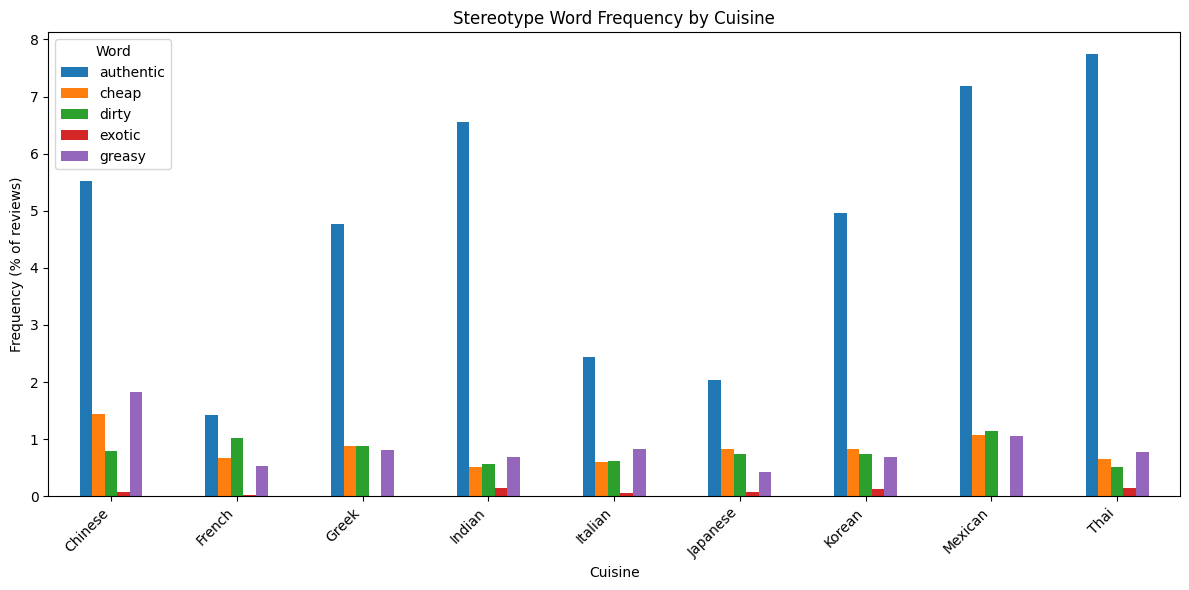

In [22]:
# calculate chi-square tests for each stereotype word category
chi_rows = []
for category in stereotype_words:
    table = []
    for cuisine in cuisines_sorted:
        c_mask = word_df["cuisine_type"] == cuisine
        total = int(c_mask.sum())
        count = int(
            stereo_freq_df.loc[
                (stereo_freq_df["cuisine"] == cuisine)
                & (stereo_freq_df["stereotype_category"] == category),
                "count",
            ].iloc[0]
        )
        table.append([count, max(total - count, 0)])

    table = np.array(table)
    if table.sum() == 0 or table.shape[0] < 2 or table[:, 0].sum() == 0:
        chi2_stat, p_val = np.nan, np.nan
    else:
        chi2_stat, p_val, _, _ = chi2_contingency(table)

    chi_rows.append({"category": category, "chi2_stat": chi2_stat, "p_value": p_val})

chi_df = pd.DataFrame(chi_rows)
display(chi_df)

# stop words
stop_words = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for", "of", "with",
    "is", "was", "were", "been", "be", "have", "has", "had", "do", "does", "did", "doing",
    "am", "are", "isn", "wasn", "weren", "don", "didn", "doesn", "won", "wouldn", "shouldn",
    "can", "could", "may", "might", "must", "shall", "will", "would", "should",
    "i", "me", "my", "mine", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours",
    "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself",
    "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "this", "that", "these", "those",
    "there", "here", "where", "when", "who", "whom", "whose", "which", "what", "why", "how",
    "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "only", "own", "same",
    "so", "than", "too", "very", "really", "just", "also", "still", "even", "much", "many", "lot", "lots",
    "not", "no", "nor", "if", "then", "because", "while", "into", "onto", "over", "under", "again",
    "up", "down", "out", "off", "as", "from", "by", "about", "after", "before", "during", "through",
    "food", "restaurant", "place", "good", "great", "nice", "bad", "best", "better", "worst",
    "service", "staff", "menu", "ordered", "order", "got", "get", "came", "come", "went", "go",
    "one", "two", "three", "first", "last", "always", "never", "ever", "make", "made",
}

# extra non-informative contractions/fragments common in Yelp text tokenization
stop_words.update({"im", "ive", "id", "ill", "youre", "youve", "youll", "theyre", "theyve", "weve", "cant", "couldnt", "didnt", "doesnt", "dont", "isnt", "wasnt", "werent", "wouldnt", "shouldnt", "wont", "thats", "theres", "heres"})

# find top words for each cuisine
word_pattern = re.compile(r"[a-z]+")
top_words_map = {}
for cuisine in cuisines_sorted:
    c_text = text_series[word_df["cuisine_type"] == cuisine]
    counter = Counter()
    for t in c_text:
        tokens = word_pattern.findall(t.lower())
        tokens = [w for w in tokens if len(w) >= 3 and w not in stop_words]
        counter.update(tokens)
    top20 = counter.most_common(20)
    top_words_map[cuisine] = top20

top_words_rows = []
for cuisine, pairs in top_words_map.items():
    for rank, (word, count) in enumerate(pairs, start=1):
        top_words_rows.append({"cuisine": cuisine, "rank": rank, "word": word, "count": int(count)})

top_words_df = pd.DataFrame(top_words_rows)
display(top_words_df)

# compare word frequencies for specific words
compare_words = ["cheap", "authentic", "dirty", "exotic", "greasy"]
compare_rows = []
for cuisine in cuisines_sorted:
    c_mask = word_df["cuisine_type"] == cuisine
    total = int(c_mask.sum())
    c_text = text_series.loc[c_mask]
    for w in compare_words:
        if total == 0:
            freq = 0.0
        else:
            has = c_text.str.contains(rf"\b{re.escape(w)}\b", regex=True, case=False, na=False)
            freq = float(has.mean())
        compare_rows.append({"cuisine": cuisine, "word": w, "frequency": freq})

compare_df = pd.DataFrame(compare_rows)
plot_df = compare_df.pivot(index="cuisine", columns="word", values="frequency").fillna(0.0)

ax = (plot_df * 100).plot(kind="bar", figsize=(12, 6))
ax.set_title("Stereotype Word Frequency by Cuisine")
ax.set_xlabel("Cuisine")
ax.set_ylabel("Frequency (% of reviews)")
ax.legend(title="Word")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
